In [4]:
import pandas as pd
import numpy as np
from scipy import stats
import seaborn as sns
import matplotlib.pyplot as plt
from scipy.stats import chi2_contingency

### Q1. Create new feature
We have been given a dataset containing the details of the people applied for loan.

dataset: loan.csv

We wish to create a new feature called 'NewFeature' using a linear combination of the features ApplicantIncome, LoanAmount and Credit_History, with weights 1, 3 and 7000,

i.e., data['NewFeature'] = (data["ApplicantIncome"]) + (3 * data["LoanAmount"]) + (7000 * data["Credit_History"]).

Since 'NewFeature' is a numerical feature, convert it to a categorical feature by checking whether 'NewFeature' is greater than 0.25 times the mean of 'NewFeature'. Call this feature 'Separator'.

Perform an appropriate test on the contingency table formed by the features 'Loan_Status' and 'Separator' and report the p-value. Also, report your interpretation.

Note: Drop all the rows having 'na' values before performing any operation on the data, and assume the significance level to be 5%. Also, round off the p-value to four decimal places.

In [17]:
H0 = 'the two features are independent'
HA = 'the two features are dependent'

data = pd.read_csv('../../assets/loan.csv')
data.dropna(inplace=True)

data['NewFeature'] = (data["ApplicantIncome"]) + (3 * data["LoanAmount"]) + (7000 * data["Credit_History"])
data['Separator'] = (data['NewFeature']>(0.25*data['NewFeature'].mean())).astype('int')
cross_tab = pd.crosstab(index=data['Separator'], columns=data['Loan_Status'])
print(cross_tab)
c_stat, p_value, dof, expected = chi2_contingency(cross_tab)
print(f'c_stat is {c_stat}, p_value:{p_value:.4f}')

alpha = 0.05
if p_value < alpha:
    print(f'Reject H0 means: {HA}')
else:
    print(f'Fail to reject H0 means: {H0}')

Loan_Status    N    Y
Separator            
0             11    2
1            137  330
c_stat is 15.62341983693342, p_value:0.0001
Reject H0 means: the two features are dependent


# Q3. Skeweness

In [5]:
data=pd.Series([38,36,31,30,20,28,25,26,19,21,19,21,20,21,21,20,21,24,32,35,38,38])
skew_value = data.skew()
print("Skewness of the dataset is:", skew_value)
if skew_value > 0:
    print("The dataset is positively/Right skewed.")
elif skew_value < 0:
    print("The dataset is negatively/Left skewed.")
else:
    print("The dataset is symmetric.")

Skewness of the dataset is: 0.5665134801986446
The dataset is positively/Right skewed.


### Q4. What's the distribution called?
<p>
Data distributions can be named based on the kurtosis value. Specifically, for given kurtosis k :

If k = 3, it is called a Mesokurtic distribution and has kurtosis statistics similar to a normal distribution.

For k > 3, it is called a Leptokurtic distribution (has a profound number of outliers)

And for k < 3, it is called a Platykurtic distribution (shows lack of outliers).

Based on this information, given a data sample [4, 6, 2, 18, 7, 2], what would be this kind of distribution called?
</p>

In [20]:
data = pd.Series([4, 6, 2, 18, 7, 2])
data.mean(),data.median(),data.mode(), data.skew()

data.kurt()

np.float64(3.7162188375322973)

### Q6. Loan applicant & Credit history
In the loan.csv dataset, we want to test whether there is a significant association between an applicant’s gender and their credit history among those who were rejected for a loan.

Use an appropriate test to verify this claim (Ensure that you drop all nan rows), and report your interpretation.

Note: Use a significance level of 5%.

In [35]:
H0 = 'Credit History and Gender are independent'
HA = 'Credit History and Gender are dependent'

data = pd.read_csv('../../assets/loan.csv')
data = data[['Gender','Credit_History','Loan_Status']]
data = data.dropna(subset=['Gender', 'Credit_History', 'Loan_Status'])


df_rejected = data[data['Loan_Status'] == 'N']

contingency_table = pd.crosstab(data['Gender'], data['Credit_History'])
chi2_contingency(contingency_table)

Chi2ContingencyResult(statistic=np.float64(0.05384950259015772), pvalue=np.float64(0.8164953298683041), dof=1, expected_freq=array([[ 15.73550725,  85.26449275],
       [ 70.26449275, 380.73550725]]))

# Q8. Daily website traffic

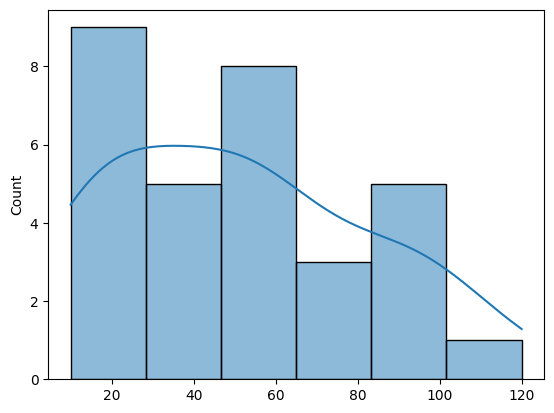

Skewness of the dataset is: 0.43087199198050025
The dataset is positively/Right skewed.
Skewness of the dataset is: 0.43087199198050025
Kurtosis of the dataset is: -0.823086089059716


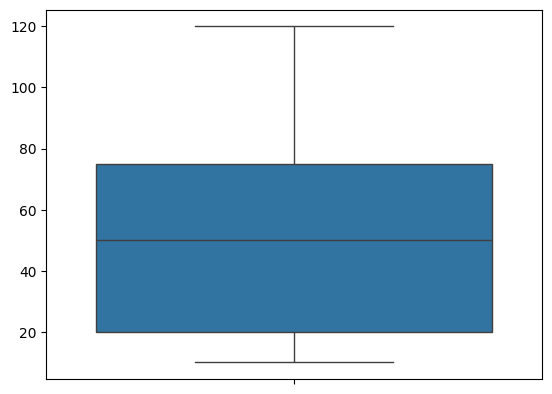

Mean: 51.29032258064516
Median: 50.0
Mode: 20


In [20]:


data = [10, 20, 20 , 40, 50, 60, 70, 60, 50, 40, 30, 20, 10, 10, 10, 20, 20, 30, 40, 50, 50, 60, 60, 80, 90, 100, 100, 120, 100, 90, 80]
skew_value = pd.Series(data).skew()

sns.histplot(data, kde=True)
plt.show()

print("Skewness of the dataset is:", skew_value)
if skew_value > 0:
    print("The dataset is positively/Right skewed.")
elif skew_value < 0:
    print("The dataset is negatively/Left skewed.")
else:
    print("The dataset is symmetric.")
print("Skewness of the dataset is:", skew_value)
print("Kurtosis of the dataset is:", pd.Series(data).kurt())

sns.boxplot(data)
plt.show()

mean = np.mean(data)
median = np.median(data)
mode = stats.mode(data, keepdims=True)[0][0]
print("Mean:", mean)
print("Median:", median)
print("Mode:", mode)